# Домашна работа 1
### По "Машинно самообучение и извличане на закономерности от данни"
### На Петър Колев, ФН: 1MI3400571

## Изследователски анализ на данните (Exploratory Data Analysis)

### Целева колона
- Целевата колона не е налична в "суровите" данни - трябва ние да си я създадем
- Решаваме класификационна задача - трябва ни целева колона, която има две стойности `0` за ресторанти с нисък рейтинг и `1` за ресторанти с висок рейтинг
- Целевата колона трябва да се базира на характеристиката `rate`
- За целта нека видим как изглеждат данните в колоната `rate`

In [33]:
import os
import zipfile
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

DATA_FOLDER = "DATA"
CSV_FILENAME = "restaurant_clf.csv"
ZIP_FILENAME = "restaurant_clf.zip"
CSV_PATH = os.path.join(DATA_FOLDER, CSV_FILENAME)
ZIP_PATH = os.path.join(DATA_FOLDER, ZIP_FILENAME)

FEATURE_DEPENDENT_ON_TARGET = "rate"

if os.path.exists(CSV_PATH):
    print(f"Loading CSV directly from: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH, delimiter=',', index_col=0)

else:
    print(f"CSV not found at {CSV_PATH}.")

    if os.path.exists(ZIP_PATH):
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extract(CSV_FILENAME, DATA_FOLDER)

        df = pd.read_csv(CSV_PATH, delimiter=',', index_col=0)
        print("CSV extracted and loaded successfully.")
    else:
        raise FileNotFoundError(
            f"Neither {CSV_FILENAME} nor {ZIP_FILENAME} were found in the DATA folder."
        )

total_examples = len(df)
missing_rate_examples = df[FEATURE_DEPENDENT_ON_TARGET].isna().sum()
unique_values = sorted(set(df[FEATURE_DEPENDENT_ON_TARGET].astype(str)))

print("Total number of examples:", total_examples)
print("Number of examples with missing 'rate':", missing_rate_examples)
print("Unique values in 'rate':", unique_values)

CSV not found at DATA/restaurant_clf.csv.
CSV extracted and loaded successfully.
Total number of examples: 51717
Number of examples with missing 'rate': 7775
Unique values in 'rate': ['-', '1.8 /5', '1.8/5', '2.0 /5', '2.0/5', '2.1 /5', '2.1/5', '2.2 /5', '2.2/5', '2.3 /5', '2.3/5', '2.4 /5', '2.4/5', '2.5 /5', '2.5/5', '2.6 /5', '2.6/5', '2.7 /5', '2.7/5', '2.8 /5', '2.8/5', '2.9 /5', '2.9/5', '3.0 /5', '3.0/5', '3.1 /5', '3.1/5', '3.2 /5', '3.2/5', '3.3 /5', '3.3/5', '3.4 /5', '3.4/5', '3.5 /5', '3.5/5', '3.6 /5', '3.6/5', '3.7 /5', '3.7/5', '3.8 /5', '3.8/5', '3.9 /5', '3.9/5', '4.0 /5', '4.0/5', '4.1 /5', '4.1/5', '4.2 /5', '4.2/5', '4.3 /5', '4.3/5', '4.4 /5', '4.4/5', '4.5 /5', '4.5/5', '4.6 /5', '4.6/5', '4.7 /5', '4.7/5', '4.8 /5', '4.8/5', '4.9 /5', '4.9/5', 'NEW', 'nan']


- Забелязваме, че има екземпляри, в които стойността на `rate` или липсва, или с някаква стойност, която не ни носи нищо - `-`, `NEW`, `nan`
- Ще премахнем тези екземпляри
- Ще преобразуваме стойностите за останалите екземпляри, като оставим само частта преди `/` и конвертираме към дробно число

In [2]:
INVALID_VALUES = ["-", "NEW", "nan"]

df = df[~df[FEATURE_DEPENDENT_ON_TARGET].isin(INVALID_VALUES)].copy()
df = df.dropna(subset=[FEATURE_DEPENDENT_ON_TARGET])
df[FEATURE_DEPENDENT_ON_TARGET] = df[FEATURE_DEPENDENT_ON_TARGET].str.strip()
df[FEATURE_DEPENDENT_ON_TARGET] = df[FEATURE_DEPENDENT_ON_TARGET].str.split("/").str[0]
df[FEATURE_DEPENDENT_ON_TARGET] = df[FEATURE_DEPENDENT_ON_TARGET].astype(float)
total_examples = len(df)
missing_rate_examples = df[FEATURE_DEPENDENT_ON_TARGET].isna().sum()
unique_values = sorted(set(df[FEATURE_DEPENDENT_ON_TARGET].astype(float)))

print("Total number of examples:", total_examples)
print("Number of examples with missing 'rate':", missing_rate_examples)
print("Unique values in 'rate':", unique_values)

Total number of examples: 41665
Number of examples with missing 'rate': 0
Unique values in 'rate': [1.8, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9]


- Ще изчислим медианата на тези стойности
- Базирайки се на медианата, ще създадем нашата целева колона `has_high_rating`
- Ще премахнем колоната `rate`, защото те я линейно зависима от целевата колона

In [3]:
TARGET = "has_high_rating"

median_rate = df[FEATURE_DEPENDENT_ON_TARGET].median()
print("Median 'rate':", median_rate)

df[TARGET] = (df[FEATURE_DEPENDENT_ON_TARGET] >= median_rate).astype(int)
df = df.drop(columns=[FEATURE_DEPENDENT_ON_TARGET])

print(df[TARGET].value_counts())

Median 'rate': 3.7
has_high_rating
1    24065
0    17600
Name: count, dtype: int64


### Характеристики
- Трябва да изберем кои характеристики са значими, за да разберем дали един ресторант има висок рейтинг, или не
- Със сигурност премахваме колоните `url`, `address`, `name` и `phone`, тъй като това са идентификатори на ресторанти и те сами по себе си не ни дават информация за това колко висок рейтинг има даден ресторант
- Премахваме колоната `reviews_list` - информацията от тази колона се представя много по структурирано от колоните `rate` и `votes`
- Премахваме колоната `menu_item`, защото тя не носи никаква информация за това колко висок рейтинг има даден ресторант, а просто изброява някакви ястия
- Колоните `location` и `listed_in(city)` са доста подобни - ще видя по колко клава имат и двете характеристики и ще оставя само тази с по-малко класове

In [4]:
FEATURES_TO_REMOVE = ["name", "url", "address", "phone", "menu_item", "reviews_list"]
df = df.drop(columns=FEATURES_TO_REMOVE)

In [5]:
print(df["location"].value_counts())
print("Number of unique `location`:", df["location"].nunique())

print(df["listed_in(city)"].value_counts())
print("Number of unique `listed_in(city)`:", df["listed_in(city)"].nunique())

location
BTM                      3930
Koramangala 5th Block    2319
HSR                      2019
Indiranagar              1847
JP Nagar                 1717
                         ... 
Yelahanka                   5
West Bangalore              3
Rajarajeshwari Nagar        2
Nagarbhavi                  1
Peenya                      1
Name: count, Length: 92, dtype: int64
Number of unique `location`: 92
listed_in(city)
BTM                      2610
Koramangala 7th Block    2390
Koramangala 4th Block    2280
Koramangala 5th Block    2277
Koramangala 6th Block    2144
Jayanagar                1928
JP Nagar                 1649
Indiranagar              1555
MG Road                  1532
Church Street            1525
Brigade Road             1484
Lavelle Road             1458
Residency Road           1358
HSR                      1340
Marathahalli             1314
Bannerghatta Road        1217
Whitefield               1214
Old Airport Road         1208
Brookefield              1150
Basav

- Ще оставя само колоната `listed_in(city)` и ще я преобразувам до числа в интервала [0, 29]

In [6]:
df = df.drop(columns=["location"])
df["listed_in(city)"] = df["listed_in(city)"].astype("category").cat.codes

print(df["listed_in(city)"].value_counts())

listed_in(city)
0     2610
19    2390
16    2280
17    2277
18    2144
13    1928
12    1649
11    1555
21    1532
7     1525
5     1484
20    1458
27    1358
10    1340
23    1314
2     1217
29    1214
25    1208
6     1150
3     1072
28    1039
15    1034
14    1006
4      971
9      957
22     947
26     878
8      828
1      728
24     572
Name: count, dtype: int64


- характеристиката `dish_liked` представлява списък от ястия, които са харесвани в даден ресторант
- може би колкото повече ястия са харесвани в даден ресторант, толкова по-висок рейтинг ще има
- ще трансформирам тази характеристика в числова такава - за всеки екземпляр ще запиша колко харесвани ястия има
- ако стойността липсва, ще поставя `0`

In [7]:
df["dish_liked"] = df["dish_liked"].fillna("")
df["dish_liked"] = df["dish_liked"].apply(lambda x: len([d for d in x.split(",") if d.strip() != ""]))

print(df["dish_liked"].value_counts())

dish_liked
0    18203
7    13810
2     1989
3     1805
1     1725
4     1571
5     1362
6     1200
Name: count, dtype: int64


- колоните `rest_type` и `cuisines` са малко по-сложни за обработка
- всеки екземпляр може да има повече от един клас за която и да е от двете харектеристики
- различни подходи за справяне с тези две характеристики са:
    - one-hot encoding и за двете характеристики, но това ще довече до супер много характеристики (+129 характеристики)
    - за всяка от двете характеристики да избера топ `N` класа и останлите да причисля към `Others`, но това `N` може би ще се намери трудно
    - да направя по-дълбок анализ на различните класове и да обединявам близките в общи класове, но това ще е много времеотнемащо (`cuisines` има 104 класа)
    - да използвам `PCA` (напр. с 2 компонента) или `K means`, или `Hierarchical clustering`,и подобни, но не съм чел упражнението за Unsupervised learning 🙈
- засега ще премахна тези характеристики, ще ги адресирам на по-късен етап

In [8]:
def explore_comma_separated_feature(df, feature_name):
    counts = {}
    combination_counts = {}
    length_counts = {}

    for entry in df[feature_name].dropna():
        items = [c.strip() for c in str(entry).split(",")]
        items = [c for c in items if c]

        for c in items:
            counts[c] = counts.get(c, 0) + 1

        combo = tuple(sorted(items))
        combination_counts[combo] = combination_counts.get(combo, 0) + 1

        n_classes = len(items)
        length_counts[n_classes] = length_counts.get(n_classes, 0) + 1


    print(feature_name.upper())
    print(f"Total unique types: {len(counts)}")
    print(f"Total unique combinations: {len(combination_counts)}")
    print("Number of classes per example:")
    for n_classes in sorted(length_counts.keys()):
        print(f"- {n_classes} class(es): {length_counts[n_classes]} example(s)")

explore_comma_separated_feature(df, "cuisines")
explore_comma_separated_feature(df, "rest_type")

df = df.drop(columns=["cuisines", "rest_type"])

CUISINES
Total unique types: 105
Total unique combinations: 1699
Number of classes per example:
- 1 class(es): 8960 example(s)
- 2 class(es): 13972 example(s)
- 3 class(es): 10303 example(s)
- 4 class(es): 5341 example(s)
- 5 class(es): 1894 example(s)
- 6 class(es): 633 example(s)
- 7 class(es): 386 example(s)
- 8 class(es): 165 example(s)
REST_TYPE
Total unique types: 24
Total unique combinations: 66
Number of classes per example:
- 1 class(es): 35056 example(s)
- 2 class(es): 6460 example(s)


- със сигурност ще използвам колоните `online_order`, `book_table`, `votes`, `approx_cost(for two people)`, `listed_in(type)`
- колоните `online_order`, `book_table`, `listed_in(type)` трябва от категорийни да станат числови
- колоната `approx_cost(for two people)` трябва от низова да стане числова

In [9]:
CATEGORICAL_FEATURES = ["online_order", "book_table", "listed_in(type)"]
STRING_FEATURE = ["approx_cost(for two people)"]

for col in CATEGORICAL_FEATURES:
    df[col] = df[col].astype("category").cat.codes


for col in STRING_FEATURE:
    df[col] = df[col].str.replace(",", "").astype(float)

print(df)

       online_order  book_table  votes  dish_liked  \
0                 1           1    775           7   
1                 1           0    787           7   
2                 1           0    918           7   
3                 0           0     88           1   
4                 0           0    166           2   
...             ...         ...    ...         ...   
51709             0           0     34           0   
51711             0           0     81           2   
51712             0           0     27           0   
51715             0           1    236           3   
51716             0           0     13           0   

       approx_cost(for two people)  listed_in(type)  listed_in(city)  \
0                            800.0                0                1   
1                            800.0                0                1   
2                            800.0                0                1   
3                            300.0                0            

In [10]:
FEATURES = df.columns.tolist()
FEATURES.remove(TARGET)

print("FEATURES:", FEATURES)
print("TARGET:", TARGET)

FEATURES: ['online_order', 'book_table', 'votes', 'dish_liked', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']
TARGET: has_high_rating


- Останахме със 7 характеристики - `online_order`, `book_table`, `votes`, `dish_liked`, `approx_cost(for two people)`, `listed_in(type)` и `listed_in(city)`
- Целевата ни колона е `has_high_rating`
- За всяка от тези характеристики ще направим разширен анализ

In [11]:
def build_summary(df):
    summary = pd.DataFrame(index=df.columns)

    numeric_desc = df.describe().T
    summary = summary.join(numeric_desc, how="left")

    num_missing = df.isna().sum()
    pct_missing = num_missing / len(df)
    num_unique = df.nunique(dropna=True)
    pct_unique = num_unique / len(df)

    summary["NUM_MISSING"] = num_missing
    summary["%_MISSING"] = pct_missing
    summary["NUM_UNIQUE"] = num_unique
    summary["%_UNIQUE"] = pct_unique

    summary = summary.round(2)

    return summary

summary = build_summary(df)
display(summary)

,count,mean,std,min,25%,50%,75%,max,NUM_MISSING,%_MISSING,NUM_UNIQUE,%_UNIQUE
online_order,41665.0,0.65,0.48,0.0,0.0,1.0,1.0,1.0,0,0.00,2,0.00
book_table,41665.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0,0,0.00,2,0.00
votes,41665.0,351.65,881.80,0.0,21.0,73.0,276.0,16832.0,0,0.00,2325,0.06
dish_liked,41665.0,3.07,3.14,0.0,0.0,2.0,7.0,7.0,0,0.00,8,0.00
approx_cost(for two people),41418.0,603.27,464.33,40.0,300.0,500.0,700.0,6000.0,247,0.01,63,0.00
listed_in(type),41665.0,2.81,1.17,0.0,2.0,2.0,4.0,6.0,0,0.00,7,0.00
listed_in(city),41665.0,14.27,8.28,0.0,7.0,15.0,20.0,29.0,0,0.00,30,0.00
has_high_rating,41665.0,0.58,0.49,0.0,0.0,1.0,1.0,1.0,0,0.00,2,0.00


- единствената характеристика, която има липсващи стойности е `approx_cost(for two people)`
- липсващите стойности са пренебрежително малко - само `247` или `0.01%`
- просто ще отстраним екземплярите с липсващи стойности

In [12]:
df = df.dropna(subset=["approx_cost(for two people)"]).copy()
summary = build_summary(df)
display(summary)

,count,mean,std,min,25%,50%,75%,max,NUM_MISSING,%_MISSING,NUM_UNIQUE,%_UNIQUE
online_order,41418.0,0.66,0.47,0.0,0.0,1.0,1.0,1.0,0,0.0,2,0.00
book_table,41418.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0,0,0.0,2,0.00
votes,41418.0,351.73,882.70,0.0,21.0,73.0,277.0,16832.0,0,0.0,2323,0.06
dish_liked,41418.0,3.07,3.14,0.0,0.0,2.0,7.0,7.0,0,0.0,8,0.00
approx_cost(for two people),41418.0,603.27,464.33,40.0,300.0,500.0,700.0,6000.0,0,0.0,63,0.00
listed_in(type),41418.0,2.81,1.17,0.0,2.0,2.0,4.0,6.0,0,0.0,7,0.00
listed_in(city),41418.0,14.25,8.28,0.0,7.0,15.0,20.0,29.0,0,0.0,30,0.00
has_high_rating,41418.0,0.58,0.49,0.0,0.0,1.0,1.0,1.0,0,0.0,2,0.00


- за всяка от характеристиките ще направим barplot/histogram и ще направим едновариантен анализ (univariate analysis)

In [13]:
from IPython.display import Image, display

def calculate_value_counts(df):
    return {col: df[col].value_counts().sort_index() for col in df.columns}

def plot_feature(df, feature_name, value_counts):
    plt.figure(figsize=(6, 4))

    if len(value_counts.index) < 10:
        df_plot = value_counts.reset_index()
        df_plot.columns = [feature_name, "count"]
        sns.barplot(data=df_plot, x=feature_name, y="count")
        plt.title(f"Bar chart of {feature_name}")
        plt.ylabel("Count")
        plt.xlabel(feature_name)
    else:
        sns.histplot(df[feature_name], bins=30)
        plt.title(f"Histogram of {feature_name}")
        plt.ylabel("Frequency")
        plt.xlabel(feature_name)

    plt.tight_layout()
    plt.show()

features_value_counts = calculate_value_counts(df)

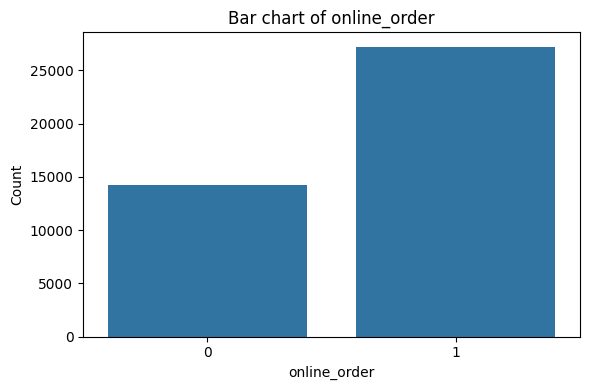

In [14]:
FEATURE = "online_order"
plot_feature(df, FEATURE, features_value_counts[FEATURE])

- ресторантите с онлайн поръчки са почти двойно повече
- нелошо разпределение

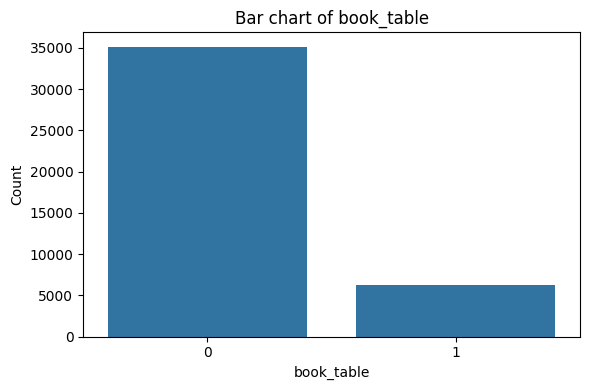

In [15]:
FEATURE = "book_table"
plot_feature(df, FEATURE, features_value_counts[FEATURE])

- ресторантите, в които можеш да си запазиш маса, са доста по-малко
- неравномерно разпределение

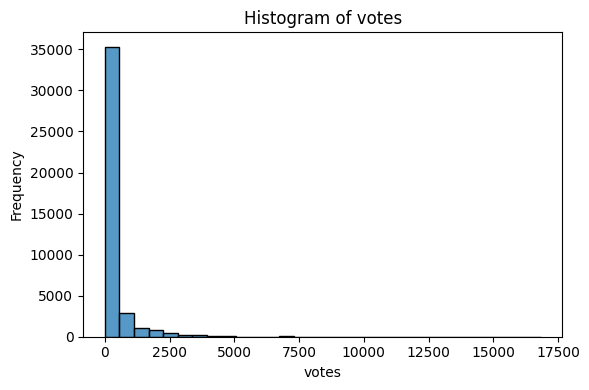

In [16]:
FEATURE = "votes"
plot_feature(df, FEATURE, features_value_counts[FEATURE])

- много силно дясно изкривяване (right skew)
- най-вероятно трябва да се направи някаква трансформация, например логаритмизация

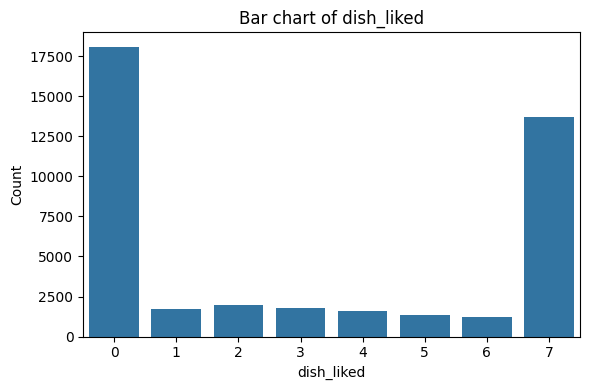

In [17]:
FEATURE = "dish_liked"
plot_feature(df, FEATURE, features_value_counts[FEATURE])

- не особено добро разпределение
- най-много ресторанти нямат нито едно посочено харесано ястие, следвани от ресторантите със 7 харесани ястия 

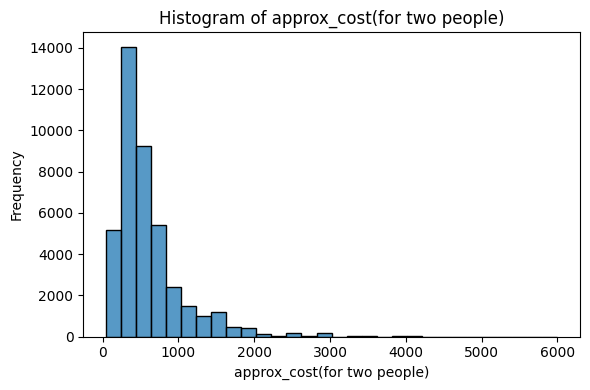

In [18]:
FEATURE = "approx_cost(for two people)"
plot_feature(df, FEATURE, features_value_counts[FEATURE])

- очевидно дясно изкривяване (right skew)
- най-вероятно трябва да се направи някаква трансформация, например логаритмизация

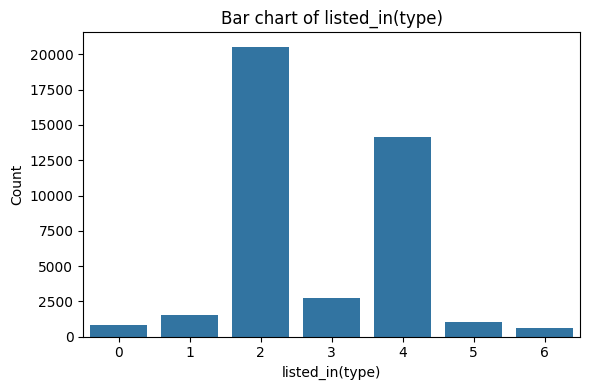

In [19]:
FEATURE = "listed_in(type)"
plot_feature(df, FEATURE, features_value_counts[FEATURE])

- не особено добро разпределение
- два от класовете имат значително повече представители

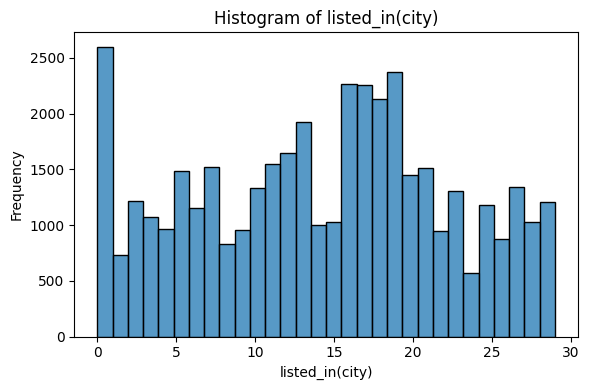

In [20]:
FEATURE = "listed_in(city)"
plot_feature(df, FEATURE, features_value_counts[FEATURE])

- сравнително добро разпределение

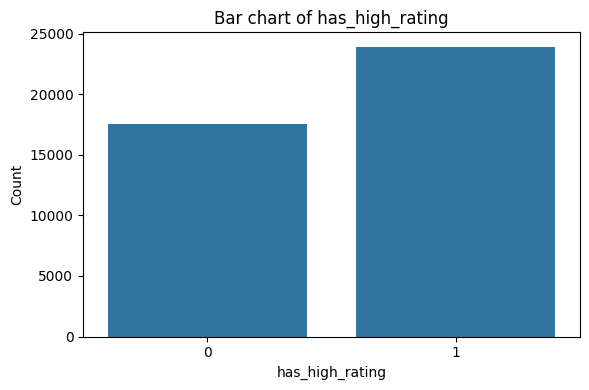

In [21]:
FEATURE = "has_high_rating"
plot_feature(df, FEATURE, features_value_counts[FEATURE])

- добро разпределение

Ще създадем pairplot, за да извършим многовариантен анализ (multivariate analysis)

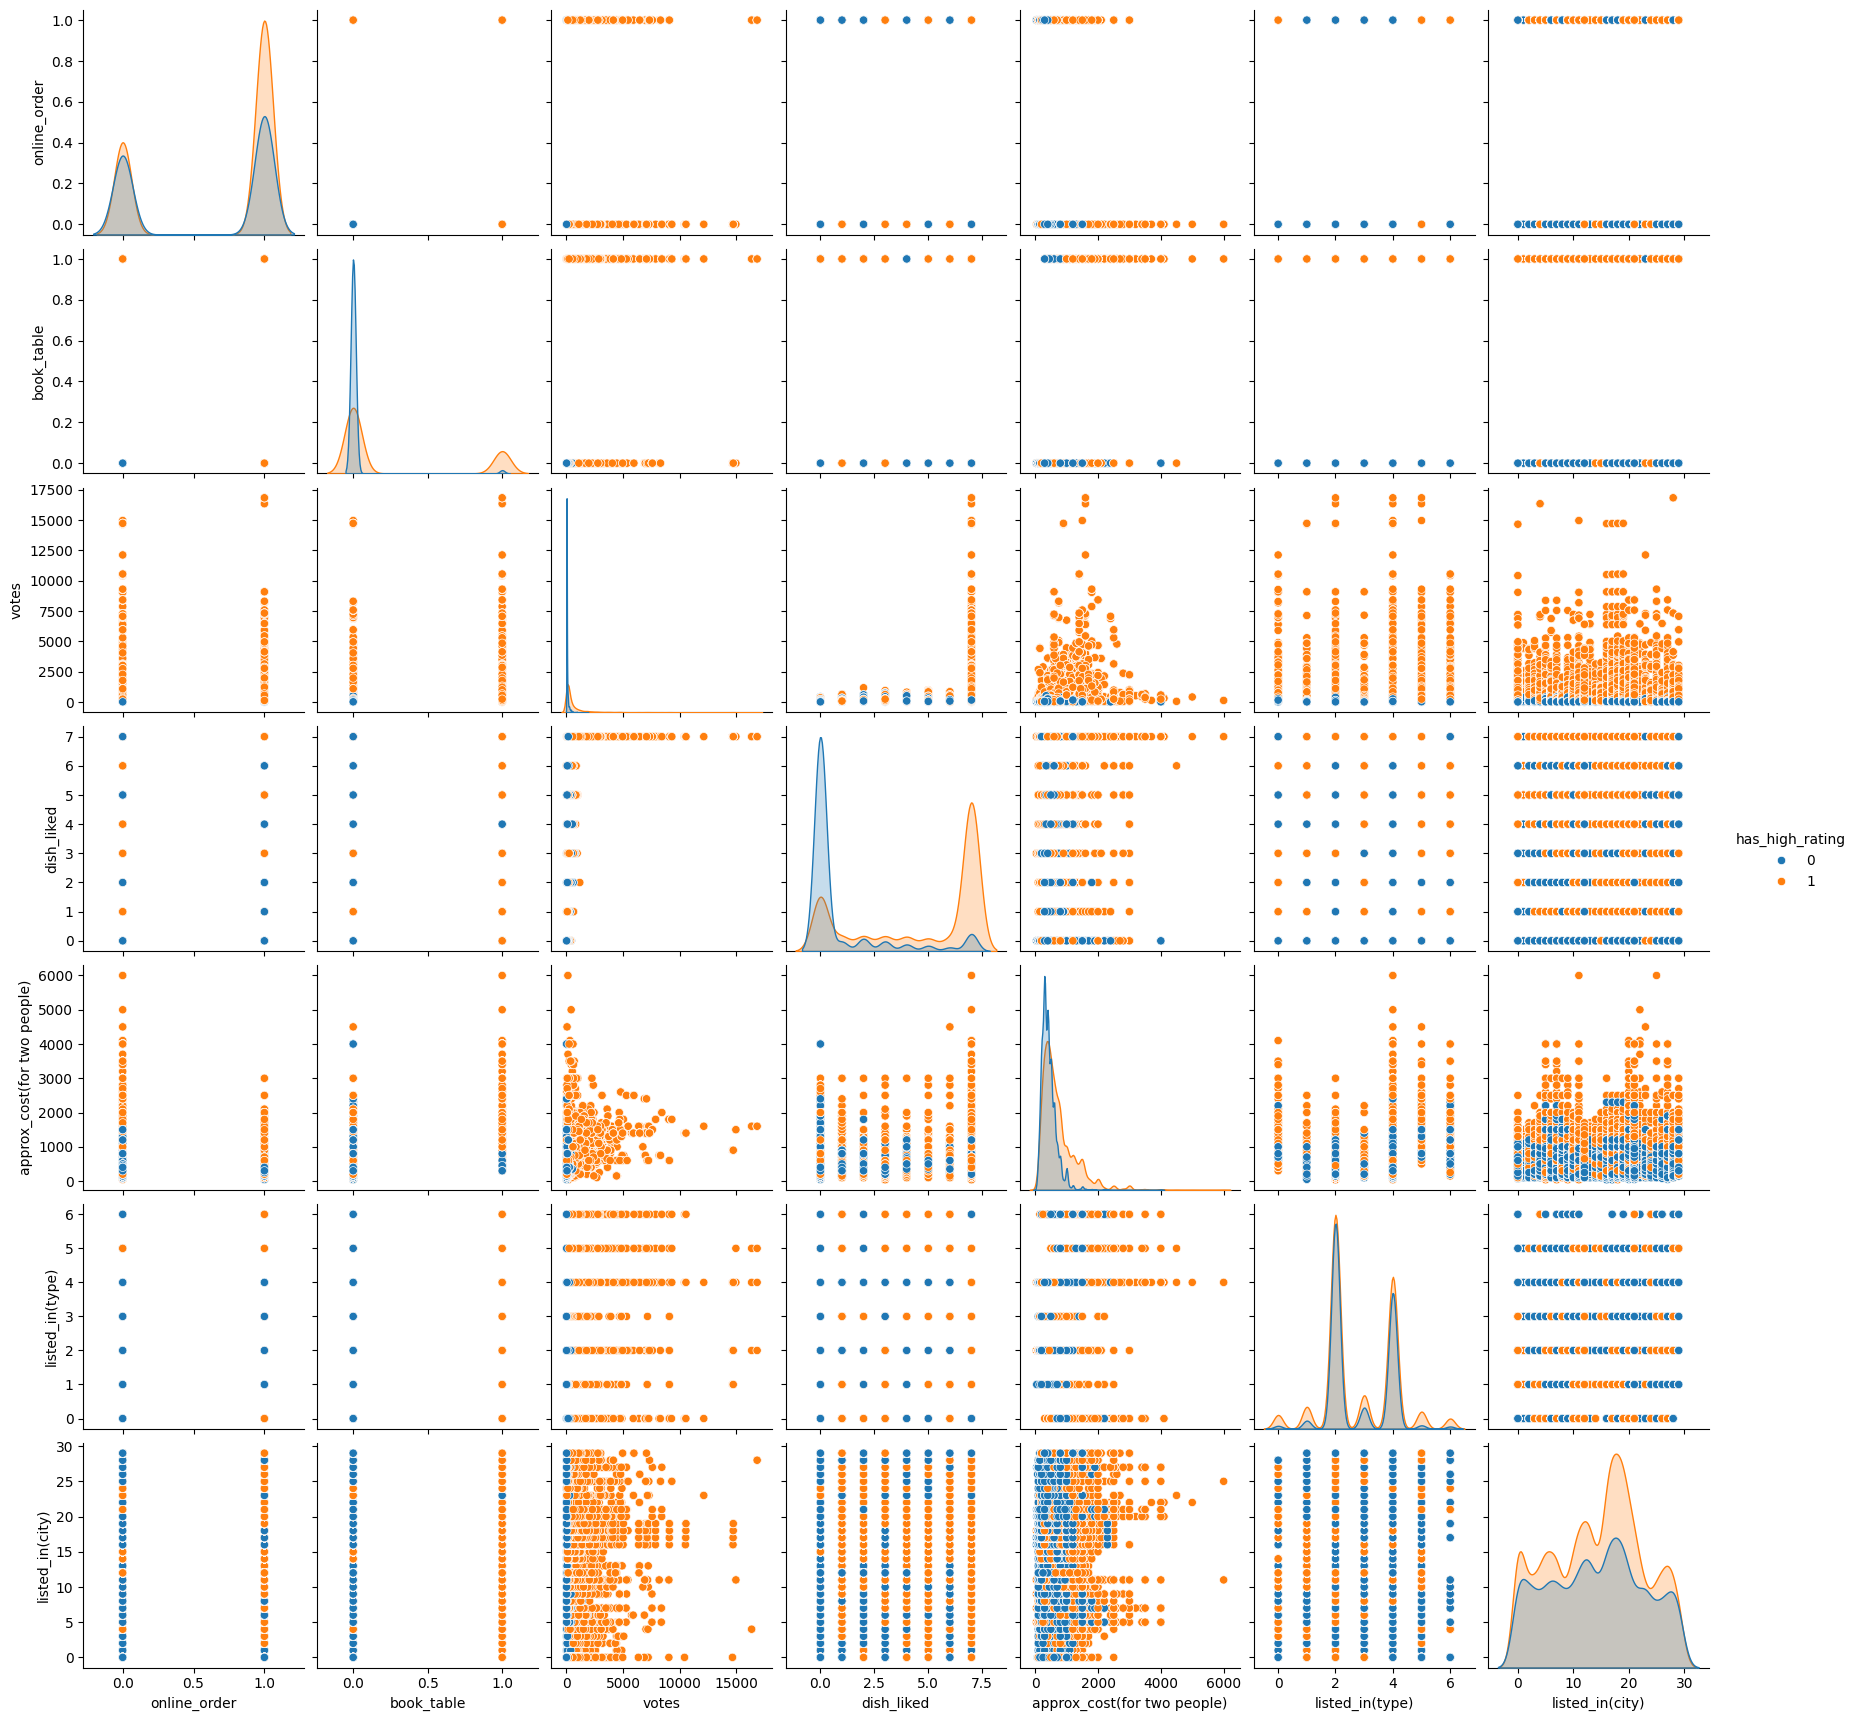

In [22]:
def plot_overwiew_pairplot(df):
    sns.pairplot(data=df, diag_kind="kde", hue=TARGET)
    plt.show()

plot_overwiew_pairplot(df)

- `dish_liked` - може би най-добрата характеристика, най-добре разделя разпределенията на целевата колона
- `book_rate` - силна характеристика, също добре разделя разпределенията на двата целеви класа
- `approx_cost(for two people)` - средно добра характеристика, има видимо разделение на разпределенията
- `votes` - слаба характеристика, доста сходни разпределения
- `online_order` - много слаба характеристика, почти еднакви разпределения
- характеристиките `listed_in(type)` и `listed_in(city)` са категорийни, за тях ще ни трябват други графики

In [23]:
def plot_categorical_predictiveness(df, feature_name):
    agg_df = (
        df.groupby(feature_name)[TARGET]
        .mean()
        .reset_index()
        .sort_values(TARGET, ascending=False)
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(data=agg_df, x=feature_name, y=TARGET)

    plt.xticks(rotation=45, ha="right")
    plt.ylabel(f"Mean {TARGET}")
    plt.xlabel(feature_name)
    plt.title(f"Predictiveness of '{feature_name}'")
    plt.tight_layout()
    plt.show()

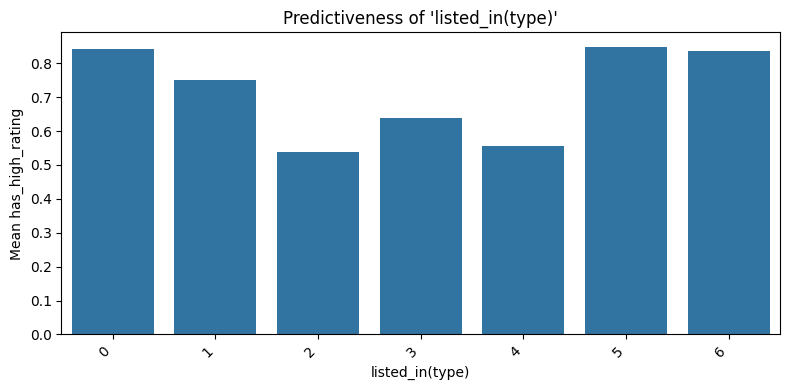

In [24]:
FEATURE = "listed_in(type)"
plot_categorical_predictiveness(df, FEATURE)

- силна характеристика - няйкои видове ресторанти са по-високо оценявани
- за линейни модели трябва да приложа one-hot encoding
- за дървета може да си остане и така

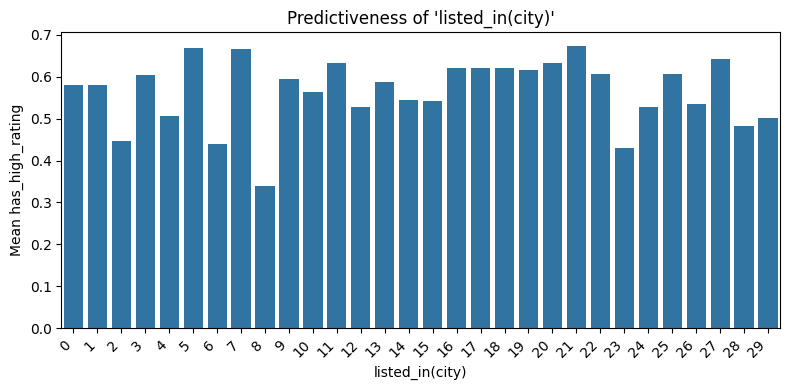

In [25]:
FEATURE = "listed_in(city)"
plot_categorical_predictiveness(df, FEATURE)

- не много добра характеристика, изглежда няма град, който да има много високи или много ниски резултати

Ако трябва да оценя характеристиките от най-силна към най-слаба, бих ги подредил така:
1. `dish_liked`
2. `book_rate`
3. `listed_in(type)`
4. `approx_cost`
5. `listed_in(city)`
6. `votes`
7. `online_order`

## Търсене на най-добър модел

За всеки модел ще следим следните метрики:
- Precision Weighted Average
- Recall Weighted Average
- F1 Weighted Average
- Confusion Matrix

### Baseliner

Ще започнем със създаването на Baseliner - модел, който винаги предвижда най-често срещания клас. След това ще сравняваме метриките на всеки модел, създаден от нас, с тези на baseliner-а и ще разглеждаме с колко процента са се увеличили стойностите. 

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

RANDOM_STATE = 21
TEST_SIZE = 0.2

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

baseline_mode = y_train.mode()[0]
baseline_y_pred = pd.Series(baseline_mode, index=y_test.index)

report = classification_report(y_test, baseline_y_pred, zero_division=0, digits=4)
cm = confusion_matrix(y_test, baseline_y_pred)

print(f"Baseline Mode Prediction: {baseline_mode:.4f}")
print("Baseline Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)

Baseline Mode Prediction: 1.0000
Baseline Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      3503
           1     0.5771    1.0000    0.7319      4781

    accuracy                         0.5771      8284
   macro avg     0.2886    0.5000    0.3659      8284
weighted avg     0.3331    0.5771    0.4224      8284

Confusion Matrix:
[[   0 3503]
 [   0 4781]]


Ще започнем с един прост модел - `DecisionTreeClassifier`, с помощта на който ще създадем графика, показваща колко важна е всяка характеристика. Така ще проверим и колко са верни разсъжденията ми от Изследователския анализ на данните.

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0     0.8442    0.8493    0.8467      3503
           1     0.8891    0.8852    0.8871      4781

    accuracy                         0.8700      8284
   macro avg     0.8666    0.8672    0.8669      8284
weighted avg     0.8701    0.8700    0.8700      8284

Confusion Matrix:
[[2975  528]
 [ 549 4232]]


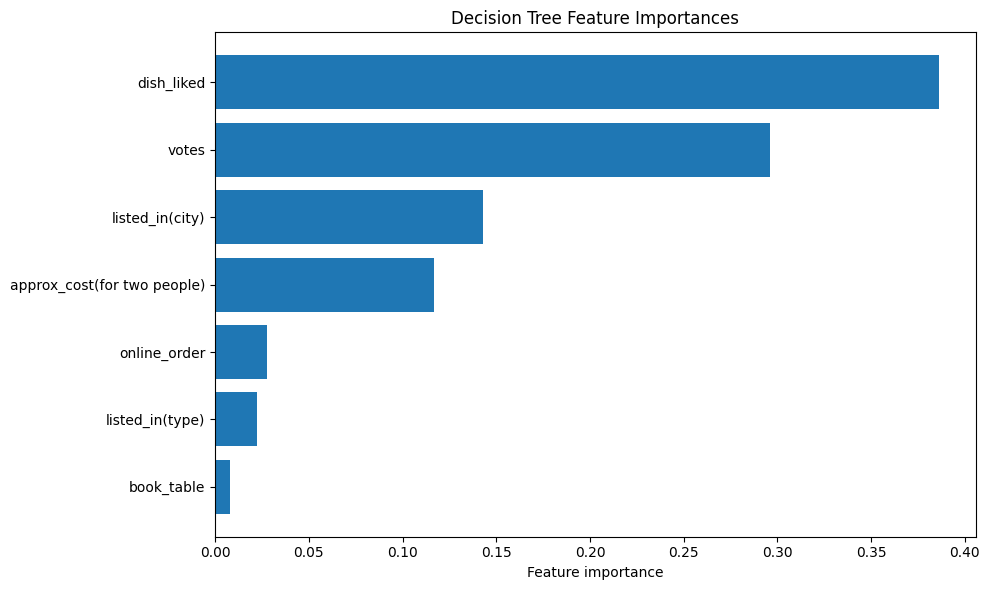

In [27]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_classifier = DecisionTreeClassifier(random_state=RANDOM_STATE)
decision_tree_classifier.fit(X_train, y_train)
y_pred = decision_tree_classifier.predict(X_test)

report = classification_report(y_test, y_pred, zero_division=0, digits=4)
cm = confusion_matrix(y_test, y_pred)

print("Decision Tree Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)

def plot_feature_importances(model, feature_names):
    importances = model.feature_importances_
    indices = np.argsort(importances)

    sorted_names = [feature_names[i] for i in indices]
    sorted_importances = importances[indices]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(sorted_importances)), sorted_importances)
    plt.yticks(range(len(sorted_importances)), sorted_names)
    plt.xlabel("Feature importance")
    plt.title("Decision Tree Feature Importances")
    plt.tight_layout()
    plt.show()

plot_feature_importances(decision_tree_classifier, FEATURES)

Изглежда заключенията ми за половината характеристики са тотално грешни 🙈
- `book_rate` и `listed_in(type)` всъщност са слаби характеристики
- `votes` и `listed_in(city)` всъщност са добри характеристики
- изглежда всички характеристики имат някаква предвиждаща сила (важността им не е 0)
- няма да премахваме характеристики засега

- Класификационното дърво значително подобрява резултата, постигнат от baseliner-a - 106.34% увеличение за F1 метриката
- Ще пробвам всички класификационни алгоритми, които сме учили досега с хиперпараметри по подразбиране
- За линейните алгоритми трябва да приложа one-hot encoding за категорийните карактеристики
- Ще започна с линейните алгоритми kNN, Logistic Regression и SVM

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

CATEGORICAL_FEATURES = ["listed_in(city)", "listed_in(type)"]

def to_one_hot_encoded_df(df):
    df_one_hot = df.copy()
    for col in CATEGORICAL_FEATURES:
        one_hot = pd.get_dummies(df_one_hot[col], prefix=col)
        df_one_hot = pd.concat([df_one_hot.drop(columns=[col]), one_hot], axis=1)
    return df_one_hot

one_hot_encoded_df = to_one_hot_encoded_df(df)

X_ohe = one_hot_encoded_df.drop(columns=[TARGET])
y_ohe = one_hot_encoded_df[TARGET]

X_ohe_train, X_ohe_test, y_ohe_train, y_ohe_test = train_test_split(
        X_ohe, y_ohe, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_ohe)

knn_classifier = KNeighborsClassifier()
logistic_regression_classifier = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
svm_classifier = SVC(random_state=RANDOM_STATE)

for model, name in [
    (knn_classifier, "K-Nearest Neighbors"),
    (logistic_regression_classifier, "Logistic Regression"),
    (svm_classifier, "Support Vector Machine"),
]:
    model.fit(X_ohe_train, y_ohe_train)
    y_ohe_pred = model.predict(X_ohe_test)

    report = classification_report(y_ohe_test, y_ohe_pred, zero_division=0, digits=4)
    cm = confusion_matrix(y_ohe_test, y_ohe_pred)

    print(f"{name} Classification Report:")
    print(report)
    print("Confusion Matrix:")
    print(cm)
    print()

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0     0.8439    0.8441    0.8440      3503
           1     0.8858    0.8856    0.8857      4781

    accuracy                         0.8681      8284
   macro avg     0.8648    0.8649    0.8648      8284
weighted avg     0.8681    0.8681    0.8681      8284

Confusion Matrix:
[[2957  546]
 [ 547 4234]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0     0.7168    0.8253    0.7673      3503
           1     0.8560    0.7611    0.8058      4781

    accuracy                         0.7883      8284
   macro avg     0.7864    0.7932    0.7865      8284
weighted avg     0.7972    0.7883    0.7895      8284

Confusion Matrix:
[[2891  612]
 [1142 3639]]



KeyboardInterrupt: 

- kNN се справи доста добре, почти толкова добре колкото класификационното дърво
- Logistic Regression и SVM се справиха по-зле
- ще опитам да приложа normalization и standardization на да проверим дали ще се подобрят

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

knn_classifier = KNeighborsClassifier()
logistic_regression_classifier = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
svm_classifier = SVC(random_state=RANDOM_STATE)

normalization_pipeline_knn = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn_classifier", knn_classifier)
])

standardization_pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn_classifier", knn_classifier)
])

normalization_pipeline_logistic = Pipeline([
    ("scaler", MinMaxScaler()),
    ("logistic_regression_classifier", logistic_regression_classifier)
])

standardization_pipeline_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression_classifier", logistic_regression_classifier)
])

normalization_pipeline_svc = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svm_classifier", svm_classifier)
])

standardization_pipeline_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_classifier", svm_classifier)
])

for pipeline, name in [
    (normalization_pipeline_knn, "K-Nearest Neighbors + Normalization"),
    (standardization_pipeline_knn, "K-Nearest Neighbors + Standardization"),
    (normalization_pipeline_logistic, "Logistic Regression + Normalization"),
    (standardization_pipeline_logistic, "Logistic Regression + Standardization"),
    (normalization_pipeline_svc, "Support Vector Machine + Normalization"),
    (standardization_pipeline_svc, "Support Vector Machine + Standardization")
]:
    pipeline.fit(X_ohe_train, y_ohe_train)
    y_ohe_pred = pipeline.predict(X_ohe_test)

    report = classification_report(y_ohe_test, y_ohe_pred, zero_division=0, digits=4)
    cm = confusion_matrix(y_ohe_test, y_ohe_pred)

    print(f"{name} Classification Report:")
    print(report)
    print("Confusion Matrix:")
    print(cm)
    print()

K-Nearest Neighbors + Normalization Classification Report:
              precision    recall  f1-score   support

           0     0.7244    0.7279    0.7262      3503
           1     0.8000    0.7971    0.7985      4781

    accuracy                         0.7679      8284
   macro avg     0.7622    0.7625    0.7624      8284
weighted avg     0.7680    0.7679    0.7679      8284

Confusion Matrix:
[[2550  953]
 [ 970 3811]]

K-Nearest Neighbors + Standardization Classification Report:
              precision    recall  f1-score   support

           0     0.7226    0.7257    0.7241      3503
           1     0.7984    0.7959    0.7971      4781

    accuracy                         0.7662      8284
   macro avg     0.7605    0.7608    0.7606      8284
weighted avg     0.7663    0.7662    0.7662      8284

Confusion Matrix:
[[2542  961]
 [ 976 3805]]

Logistic Regression + Normalization Classification Report:
              precision    recall  f1-score   support

           0     0.7

- kNN се влоши
- Logistic Regression се подобри съвесем малко
- SVC се подобри доста
- но никой линеен алгоритъм не достига метриките на класификационното дърво
- сега ще пробвам bagging и boosting алгортми
- те не се нуждаят от one-hot encoding
- за всички ще използвам като базов алгоритъм класификационно дърво, така че не ми трябва и normalization/standardization

In [30]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [ ]:
ensemble_models = [
    (RandomForestClassifier(random_state=RANDOM_STATE), "Random Forest"),
    (BaggingClassifier(random_state=RANDOM_STATE), "Bagging Classifier"),
    (AdaBoostClassifier(random_state=RANDOM_STATE), "AdaBoost Classifier"),
    (XGBClassifier(random_state=RANDOM_STATE, enable_categorical=True), "XGBoost Classifier"),
    (CatBoostClassifier(verbose=0, random_state=RANDOM_STATE), "CatBoost Classifier"),
    (LGBMClassifier(random_state=RANDOM_STATE), "LightGBM Classifier"),
]

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

for model, name in ensemble_models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, zero_division=0, digits=4)
    cm = confusion_matrix(y_test, y_pred)

    print(f"{name} Classification Report:")
    print(report)
    print("Confusion Matrix:")
    print(cm)
    print()


Random Forest Classification Report:
              precision    recall  f1-score   support

           0     0.8484    0.8193    0.8336      3503
           1     0.8708    0.8927    0.8816      4781

    accuracy                         0.8617      8284
   macro avg     0.8596    0.8560    0.8576      8284
weighted avg     0.8613    0.8617    0.8613      8284

Confusion Matrix:
[[2870  633]
 [ 513 4268]]

Bagging Classifier Classification Report:
              precision    recall  f1-score   support

           0     0.8518    0.8710    0.8613      3503
           1     0.9039    0.8889    0.8963      4781

    accuracy                         0.8813      8284
   macro avg     0.8778    0.8800    0.8788      8284
weighted avg     0.8818    0.8813    0.8815      8284

Confusion Matrix:
[[3051  452]
 [ 531 4250]]

AdaBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0     0.7659    0.7733    0.7696      3503
           1     0.8327

- с хиперпараметри по подразбиране Bagging Classifier има най-добър резултат - `0.8815` F1 метрика
- ще опитам да направя hyperparameter tuning с микроскопичен GridSearchCV за трите 3rd party boosting алгоритъма (Голямата Тройка)

Best Hyperparameters for XGBoost Classifier:
{'colsample_bytree': 1.0, 'learning_rate': 0.15, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 350, 'subsample': 0.9}
XGBoost Classifier with Hyperparameter Tuning Classification Report:
              precision    recall  f1-score   support

           0     0.8623    0.8584    0.8604      3503
           1     0.8966    0.8996    0.8981      4781

    accuracy                         0.8822      8284
   macro avg     0.8795    0.8790    0.8792      8284
weighted avg     0.8821    0.8822    0.8821      8284

Confusion Matrix:
[[3007  496]
 [ 480 4301]]


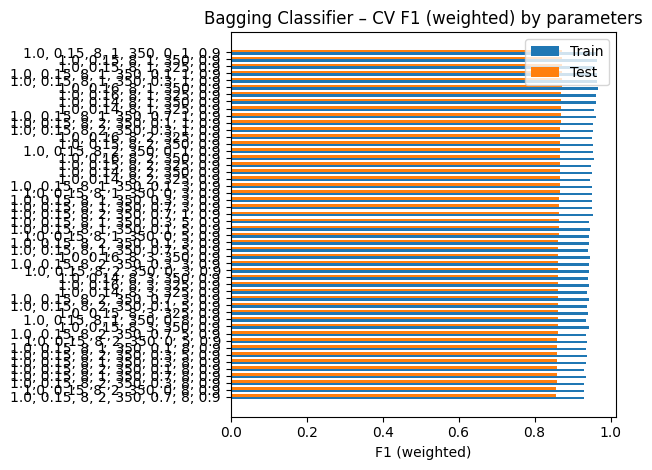

In [ ]:
from sklearn.model_selection import GridSearchCV

def grid_search(classifier):
    return GridSearchCV(classifier,
                        build_param_grid(),
                        cv=5,
                        scoring="f1_weighted",
                        return_train_score=True,
                        n_jobs=-1)

def plot_model_cv_bars(gs):
    res = pd.DataFrame(gs.cv_results_)

    res["param_label"] = res["params"].apply(
        lambda d: ", ".join(f"{v}" for _, v in d.items()))

    df = res[["param_label", "mean_train_score", "mean_test_score"]].copy()
    df = df.sort_values("mean_test_score",
                        ascending=True).reset_index(drop=True)

    y = np.arange(len(df))
    h = 0.35

    plt.figure()

    plt.barh(y - h / 2, df["mean_train_score"], height=h, label="Train")
    plt.barh(y + h / 2, df["mean_test_score"], height=h, label="Test")

    plt.yticks(y, df["param_label"])

    plt.xlabel("F1 (weighted)")
    plt.title("Bagging Classifier – CV F1 (weighted) by parameters")
    plt.legend()
    plt.tight_layout()
    plt.show()

def build_param_grid():
    return [
        {
            "n_estimators": [325, 350],
            "learning_rate": [0.16, 0.15, 0.14],
            "max_depth": [8],
            "subsample": [0.9],
            "colsample_bytree": [1.0],
            "min_child_weight": [1, 2, 3],
        },
        {
            "n_estimators": [350],
            "learning_rate": [0.15],
            "max_depth": [8],
            "subsample": [0.9],
            "colsample_bytree": [1.0],
            "reg_alpha": [0, 0.1, 0.3, 0.7],
            "reg_lambda": [1, 3, 5, 8],
            "min_child_weight": [1, 2],
        },
    ]


X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

xgb_classifier = XGBClassifier(random_state=RANDOM_STATE, enable_categorical=True)
grid_search_xgb = grid_search(xgb_classifier)
grid_search_xgb.fit(X_train, y_train)

print("Best Hyperparameters for XGBoost Classifier:")
print(grid_search_xgb.best_params_)

y_pred = grid_search_xgb.predict(X_test)

report = classification_report(y_test, y_pred, zero_division=0, digits=4)
cm = confusion_matrix(y_test, y_pred)

print("XGBoost Classifier with Hyperparameter Tuning Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)

plot_model_cv_bars(grid_search_xgb)

- успяхме да подобрим XGBoost с микроскопични GridSearchCV
- даже подобрихме с малко BaggingClassifier с хиперпараметри по подразбиране
- продължаваме с fine tuning на CatBoost

Best Hyperparameters for CatBoost Classifier:
{'border_count': 128, 'depth': 9, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.13}
CatBoost Classifier with Hyperparameter Tuning Classification Report:
              precision    recall  f1-score   support

           0     0.8597    0.8556    0.8576      3503
           1     0.8945    0.8977    0.8961      4781

    accuracy                         0.8799      8284
   macro avg     0.8771    0.8766    0.8769      8284
weighted avg     0.8798    0.8799    0.8798      8284

Confusion Matrix:
[[2997  506]
 [ 489 4292]]


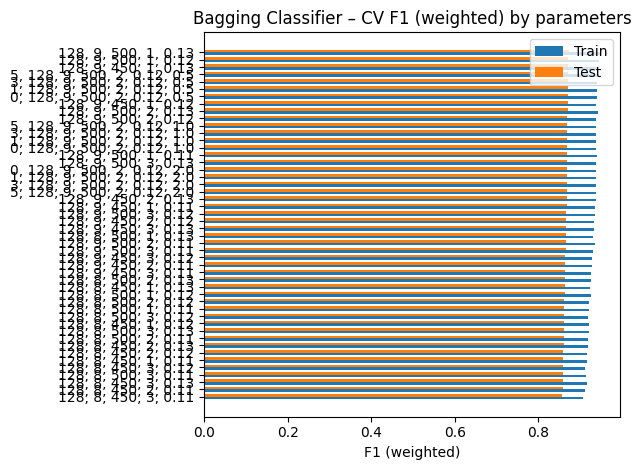

In [ ]:
def build_param_grid():
    return [
        {
            "iterations": [450, 500],
            "learning_rate": [0.13, 0.12, 0.11],
            "depth": [8, 9],
            "l2_leaf_reg": [1, 2, 3],
            "border_count": [128],
        },
        {
            "iterations": [500],
            "learning_rate": [0.12],
            "depth": [9],
            "l2_leaf_reg": [2],
            "border_count": [128],
            "bagging_temperature": [0, 1, 3, 5],
            "random_strength": [0.5, 1.0, 2.0],
        },
    ]

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

catboost_classifier = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
grid_search_catboost = grid_search(catboost_classifier)
grid_search_catboost.fit(X_train, y_train)

print("Best Hyperparameters for CatBoost Classifier:")
print(grid_search_catboost.best_params_)

y_pred = grid_search_catboost.predict(X_test)

report = classification_report(y_test, y_pred, zero_division=0, digits=4)
cm = confusion_matrix(y_test, y_pred)

print("CatBoost Classifier with Hyperparameter Tuning Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)

plot_model_cv_bars(grid_search_catboost)

- отново подобрихме модела след микроскопичен GridSearchSV
- CatBoost не успя да задмине XGBoost, но също е доста силен
- да завършим с опит за fine tuning на LGBMClassifier

Best Hyperparameters for LGBM Classifier:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 400, 'num_leaves': 63, 'subsample': 0.8}
LGBM Classifier with Hyperparameter Tuning Classification Report:
              precision    recall  f1-score   support

           0     0.8568    0.8573    0.8570      3503
           1     0.8954    0.8950    0.8952      4781

    accuracy                         0.8790      8284
   macro avg     0.8761    0.8761    0.8761      8284
weighted avg     0.8791    0.8790    0.8790      8284

Confusion Matrix:
[[3003  500]
 [ 502 4279]]


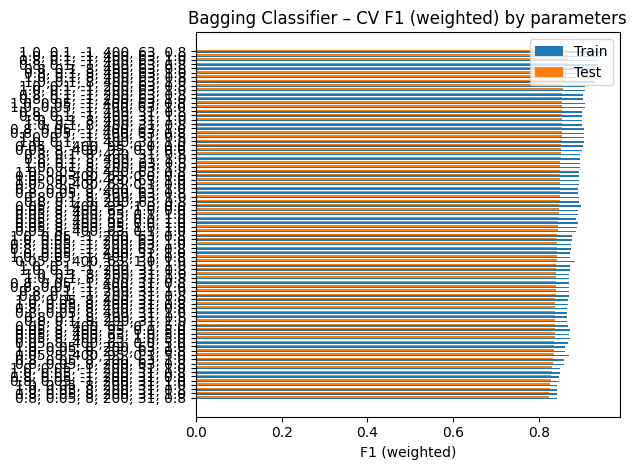

In [ ]:
def build_lgbm_refined_grid():
    return [
        {
            "n_estimators": [350, 400, 450],
            "learning_rate": [0.12, 0.1, 0.08],
            "num_leaves": [63, 80],
            "subsample": [0.8, 0.9],
            "colsample_bytree": [0.9, 1.0],
        }
    ]

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

lgbm_classifier = LGBMClassifier(random_state=RANDOM_STATE, objective='binary', verbose=-1)
grid_search_lgbm = grid_search(lgbm_classifier)
grid_search_lgbm.fit(X_train, y_train)

print("Best Hyperparameters for LGBM Classifier:")
print(grid_search_lgbm.best_params_)

y_pred = grid_search_lgbm.predict(X_test)

report = classification_report(y_test, y_pred, zero_division=0, digits=4)
cm = confusion_matrix(y_test, y_pred)

print("LGBM Classifier with Hyperparameter Tuning Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)

plot_model_cv_bars(grid_search_lgbm)

- отново подобрихме модела след микроскопичен GridSearchSV
- LGBMClassifier не успя да задмине XGBoost, но също е доста силен

## Избор на най-добър модел
- Най-добрият ни модел е `XGBoost` с хиперпараметри `{'colsample_bytree': 1.0, 'learning_rate': 0.15, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 350, 'subsample': 0.9}`
- Precision Weighted Average - `0.8821`
- Recall Weighted Average - `0.8822`
- F1 Weighted Average - `0.8821`

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

best_model = XGBClassifier(random_state=RANDOM_STATE,
                                         colsample_bytree=1.0, learning_rate=0.15, max_depth=8, min_child_samples=1, n_estimators=350, subsample=0.9)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
report = classification_report(y_test, y_pred, zero_division=0, digits=4)
cm = confusion_matrix(y_test, y_pred)

print("XGBoost Classifier with Hyperparameter Tuning Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)

/Users/petar.kolev/Documents/FMI/ML/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [01:49:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "min_child_samples" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier with Hyperparameter Tuning Classification Report:
              precision    recall  f1-score   support

           0     0.8623    0.8584    0.8604      3503
           1     0.8966    0.8996    0.8981      4781

    accuracy                         0.8822      8284
   macro avg     0.8795    0.8790    0.8792      8284
weighted avg     0.8821    0.8822    0.8821      8284

Confusion Matrix:
[[3007  496]
 [ 480 4301]]


Ще добавим малко графики за най-добрия модел:
- ROC Curve
- Precision Recall Curve
- Confusion Matrix
- Feature Importances

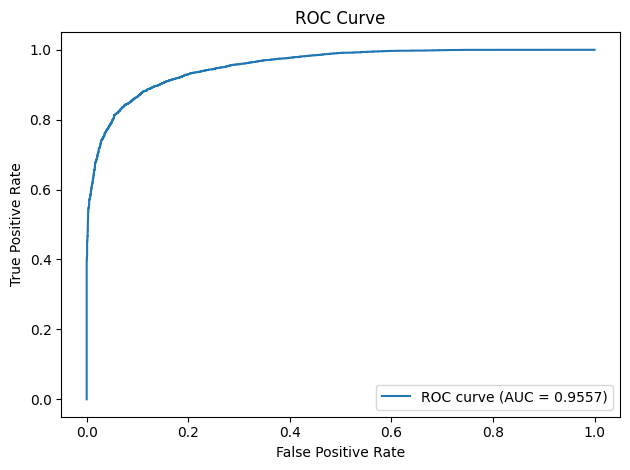

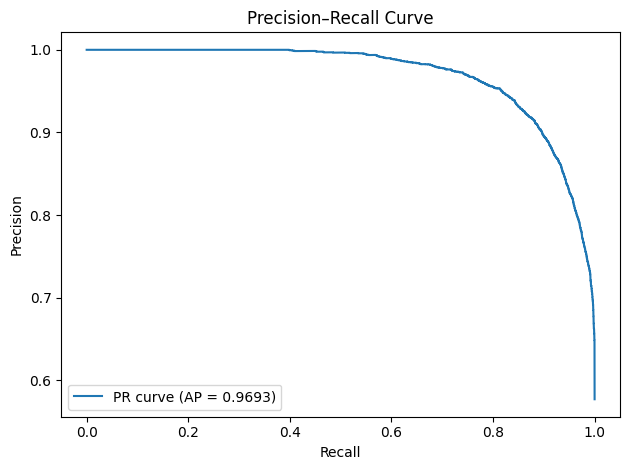

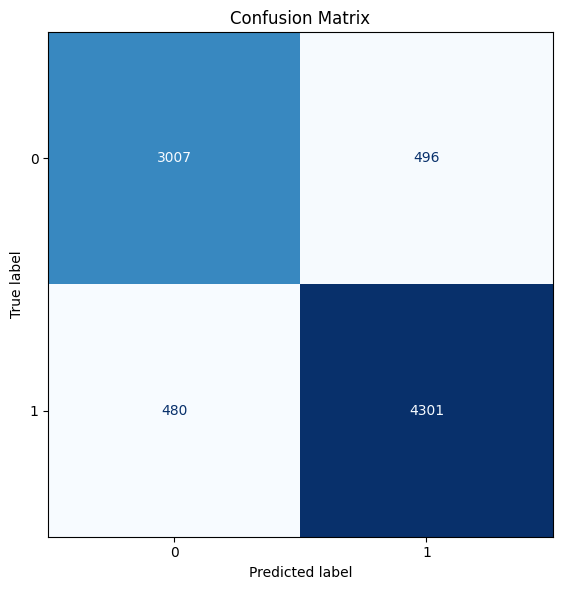

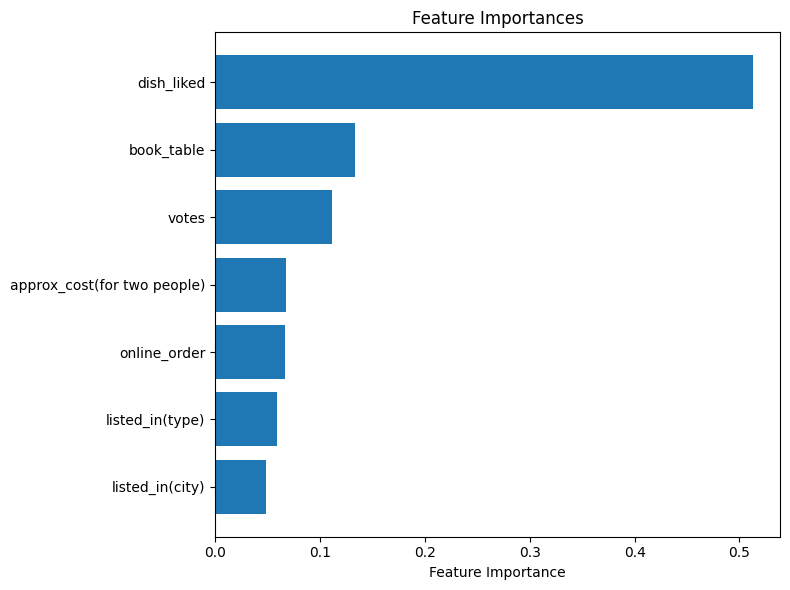

In [32]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

def plot_roc_curve(classifier, X_test, y_test):
    y_score = classifier.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

def plot_precision_recall_curve(classifier, X_test, y_test):
    y_score = classifier.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    avg_precision = average_precision_score(y_test, y_score)

    plt.figure()
    plt.plot(recall, precision, label=f'PR curve (AP = {avg_precision:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision–Recall Curve')
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(classifier, X_test, y_test):
    y_pred = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names):
    importance = model.feature_importances_
    idx = np.argsort(importance)

    plt.figure(figsize=(8, 6))
    plt.barh(range(len(idx)), importance[idx], align='center')
    plt.yticks(range(len(idx)), [feature_names[i] for i in idx])
    plt.xlabel("Feature Importance")
    plt.title("Feature Importances")
    plt.tight_layout()
    plt.show()

plot_roc_curve(best_model, X_test, y_test)
plot_precision_recall_curve(best_model, X_test, y_test)
plot_confusion_matrix(best_model, X_test, y_test)
plot_feature_importance(best_model, FEATURES)